# Excitation energy $^{16}\text{O}$ with event mixing

In [1]:
from spyral.core.constants import AMU_2_MEV, QBRHO_2_P

from spyral_utils.nuclear import NuclearDataMap
from spyral_utils.nuclear.target import GasTarget, load_target, SolidTarget
from spyral_utils.plot import Histogrammer

import polars as pl
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import vector
import lmfit
from itertools import combinations
import json
%matplotlib widget
plt.close()

nuclear_map = NuclearDataMap()
# Ion Chamber entrance and exit window, thickness in ug/cm^2
ic_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# AT-TPC entrance window, thickness in ug/cm^2
attpc_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# Ion Chamber gas material, pressure in Torr
ic_gas_material = GasTarget(compound=[(6,12,1),(9,18,4)], pressure=200.0, nuclear_data=nuclear_map)
ic_gas_thickness = 0.035 #m


In [2]:
nuclear_map = NuclearDataMap()

# Set some parameters
# workspace_path_target = Path("/Volumes/research_EXT_2/spyral_target_alpha_width3")
# workspace_path_decay = Path("/Volumes/research_EXT_2/spyral_decay_alpha_width3")

# solver_result_path_target = workspace_path_target / "InterpSolver"
# solver_result_path_decay = workspace_path_decay / "InterpSolver"
solver_result_path = Path("/Volumes/researchEXT/O16/all_analysis_spyralv1.0/all_five_tracks_analysis/14082026_all_5tracks") / "InterpSolver"
# Your AT-TPC target gas material
target_material_path = Path("/Users/pranjalsingh/Desktop/research_space_spyral/e20020_analysis/solver_gas_16O.json")

# Run number range (inclusive)
run_min = 54
run_max = 170
# Specify your nuclei

# The nucleus we observe (the one we fitted)
ejectile_z = 2
ejectile_a = 4

# The incoming nucleus (the beam)
projectile_z = 8
projectile_a = 16


channel_z = 8
channel_a = 16 

channel2_z = 4
channel2_a = 8

fusion_z = 10
fusion_a = 20

# The target nucleus
target_z = 2
target_a = 4

# We calculate the residual for you
residual_z = target_z + projectile_z - ejectile_z
residual_a = target_a + projectile_a - ejectile_a


if residual_z < 0:
    raise Exception(f"Illegal nuclei! Residual Z: {residual_z}")  # noqa: TRY002
if residual_a < 1:
    raise Exception(f"Illegal nuclei! Residual A: {residual_a}")  # noqa: TRY002


In [3]:
target_material = load_target(target_material_path, nuclear_map)
if not isinstance(target_material, GasTarget):
    print('Target error!')

ejectile = nuclear_map.get_data(ejectile_z, ejectile_a)
projectile = nuclear_map.get_data(projectile_z, projectile_a)
channel = nuclear_map.get_data(channel_z, channel_a)
channel_8be = nuclear_map.get_data(channel2_z, channel2_a)
fusion = nuclear_map.get_data(fusion_z, fusion_a)
target = nuclear_map.get_data(target_z, target_a)
residual = nuclear_map.get_data(residual_z, residual_a)
print(f"Reaction: {target}({projectile}, {ejectile}){residual}")
print(f"Target material: {target_material.ugly_string}")

# Initial beam energy
mass_amu = projectile.mass / AMU_2_MEV # If needed, to convert beam energy in MeV/u -> MeV
proj_energy_accel = 161.0 # MeV, the beam energy from the accelerator

# The beam energy after the ic entrance window
proj_energy_ic = proj_energy_accel #- ic_window_material.get_energy_loss(projectile, proj_energy_accel, np.array([0.0]))[0]
# The beam energy after the ic gas
proj_energy_ic_exit = proj_energy_ic #- ic_gas_material.get_energy_loss(projectile, proj_energy_ic, np.array([ic_gas_thickness]))[0]
# The beam energy after the ic exit window
proj_energy_post_ic = proj_energy_ic_exit #- ic_window_material.get_energy_loss(projectile, proj_energy_ic_exit, np.array([0.0]))[0]
# The beam energy after the AT-TPC entrace window
proj_energy_start = proj_energy_post_ic #- attpc_window_material.get_energy_loss(projectile, proj_energy_post_ic, np.array([0.0]))[0]
# The beam energy at the downstream end of the AT-TPC
proj_energy_stop = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, np.array([1.0]))[0] # Energy at far end of detector
print(f"Accelerator Beam energy: {proj_energy_accel} MeV")
print(f"Beam energy after IC (2 windows + gas): {proj_energy_post_ic} MeV")
print(f"Beam energy range in AT-TPC: {proj_energy_start}-{proj_energy_stop} MeV")


Reaction: 4He(16O, 4He)16O
Target material: (Gas)4He1
Accelerator Beam energy: 161.0 MeV
Beam energy after IC (2 windows + gas): 161.0 MeV
Beam energy range in AT-TPC: 161.0-110.84634259864373 MeV


In [4]:
grammer = Histogrammer()
grammer.add_hist1d('inv_12c_correlated', 40, (0, 20.0))
grammer.add_hist1d('inv_12c_uncorrelated', 40, (0, 20.0))
grammer.add_hist1d('inv_8be_correlated', 40, (0, 20))
grammer.add_hist1d('inv_8be_uncorrelated', 40, (0, 20))
grammer.add_hist1d('inv_8be_uncorrelated_method2',40, (0, 20))
grammer.add_hist1d('inv_8be_correlated_method2', 40, (0, 20))

In [5]:
concat_df = None

for run in range(run_min, run_max+ 1):
    path = solver_result_path / f"run_{run:04d}_4He.parquet"
        
    if not path.exists():
        continue

    df = pl.scan_parquet(path).collect()
    
    if concat_df is not None:
        concat_df = pl.concat([concat_df,df])
    else:
        concat_df = df
        

In [6]:
print(concat_df.shape)

(1721, 20)


In [7]:
def inverse_fermi(energy,c1,c2):
    return np.exp(-c1/c2)*(((1+np.exp(c1/c2))/(1+np.exp(-(energy-c1)/c2)))+1)

## $^{12}\text{C}$ Event Mixing

### Uncorrelated relative energy

In [8]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

counter_inv = 0
inv_energy_arr = []

c12_hoyle_energy = []
counter = 0


df = concat_df.slice(offset=0,length=400) #limited the amount of original events -> less computation

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 


wide = df.pivot(
    on="cluster_index_corr",
    index="event",
    values=["px", "py", "pz", "E"],
) #collaspsing the 5 different entries from 5 alphas into just the four momentum vector on one entry with different alphas 

# print(wide.shape)
# wide.head()

combo_frames = []
for combo_id, (i, j, k) in enumerate(combinations(range(5), 3)): #creates a list of 10 tables, one with each combination
    combo_frames.append(
        wide.select(
            pl.col("event"),
            pl.lit(combo_id).alias("combo_id"),
            (pl.col(f"px_{i}") + pl.col(f"px_{j}") + pl.col(f"px_{k}")).alias("px_tot3"),
            (pl.col(f"py_{i}") + pl.col(f"py_{j}") + pl.col(f"py_{k}")).alias("py_tot3"),
            (pl.col(f"pz_{i}") + pl.col(f"pz_{j}") + pl.col(f"pz_{k}")).alias("pz_tot3"),
            (pl.col(f"E_{i}")  + pl.col(f"E_{j}")  + pl.col(f"E_{k}")).alias("E_tot3"),
        )
    )

three_sums = pl.concat(combo_frames)

alphas_flat = df.select(["event", "px", "py", "pz", "E"]).rename(
    {"event": "event_mix", "px": "px4th", "py": "py4th", "pz": "pz4th", "E": "E4th"}
)

mixed = (
    three_sums.lazy()
    .join(alphas_flat.lazy(), how="cross")
    .filter(pl.col("event") != pl.col("event_mix")) #making sure to not include the 4th alphas as the one from the same event 
    .with_columns(
        (pl.col("px_tot3") + pl.col("px4th")).alias("Px"), #adding the four momentum vector for the 4th alpha and assigning to a total energy
        (pl.col("py_tot3") + pl.col("py4th")).alias("Py"),
        (pl.col("pz_tot3") + pl.col("pz4th")).alias("Pz"),
        (pl.col("E_tot3")  + pl.col("E4th")).alias("Etot"),
    )
    .with_columns(
        pl.max_horizontal(
            pl.col("Etot")**2 - (pl.col("Px")**2 + pl.col("Py")**2 + pl.col("Pz")**2),  #getting the inariant mass
            pl.lit(0.0),
        ).sqrt().alias("inv_mass")
    )
    .with_columns(
        (pl.col("inv_mass") - 4 * ejectile.mass).alias("rel_energy") #getting the relativ energy 
    )
    .collect(engine="streaming")
)


uncorr_total_counts = mixed.height

relative_uncorr = mixed["rel_energy"].to_list()
grammer.fill_hist1d("inv_12c_uncorrelated",relative_uncorr)


True

### Correlated Relative Energy

In [9]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

df = concat_df

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 


wide = df.pivot(
    on="cluster_index_corr",
    index="event",
    values=["px", "py", "pz", "E"],
) #collaspsing the 5 different entries from 5 alphas into just the four momentum vector on one entry with different alphas 

# print(wide.shape)
# wide.head()

combo_frames = []
for combo_id, (i, j, k, m) in enumerate(combinations(range(5), 4)): #creates a list of 10 tables, one with each combination
    combo_frames.append(
        wide.select(
            pl.col("event"),
            pl.lit(combo_id).alias("combo_id"),
            (pl.col(f"px_{i}") + pl.col(f"px_{j}") + pl.col(f"px_{k}") + pl.col(f"px_{m}")).alias("Px"),
            (pl.col(f"py_{i}") + pl.col(f"py_{j}") + pl.col(f"py_{k}") + pl.col(f"py_{m}")).alias("Py"),
            (pl.col(f"pz_{i}") + pl.col(f"pz_{j}") + pl.col(f"pz_{k}") + pl.col(f"pz_{m}")).alias("Pz"),
            (pl.col(f"E_{i}")  + pl.col(f"E_{j}")  + pl.col(f"E_{k}") + pl.col(f"E_{m}")).alias("Etot"),
        )
    )

four_sums = pl.concat(combo_frames)



mixed = (
    four_sums.lazy()
    .with_columns(
        pl.max_horizontal(
            pl.col("Etot")**2 - (pl.col("Px")**2 + pl.col("Py")**2 + pl.col("Pz")**2),  #getting the inariant mass
            pl.lit(0.0),
        ).sqrt().alias("inv_mass")
    )
    .with_columns(
        (pl.col("inv_mass") - 4 * ejectile.mass).alias("rel_energy") #getting the relativ energy 
    )
    .collect(engine="streaming")
)

corr_total_counts = mixed.height

relative_corr = mixed["rel_energy"].to_list()
grammer.fill_hist1d("inv_12c_correlated",relative_corr)


True

In [10]:
ratio_counts = corr_total_counts/uncorr_total_counts
print(f"Ratio unorr/corr counts: {ratio_counts}")

Ratio unorr/corr counts: 0.006543052003410059


Normalization factor = 0.007051103043842502

========== DIAGNOSTICS ==========
Number of bins: 40
Correlated counts:
  min = 0.0
  max = 101.0
Uncorrelated counts:
  min = 6.0
  max = 14324.0
Zero uncorrelated bins: 0

Correlation function:
  NaN: 0
  Inf: 0
  minimum = 0.0
  maximum = 1.9154751779878152

Uncertainty:
  valid bins: 37
  invalid bins: 3


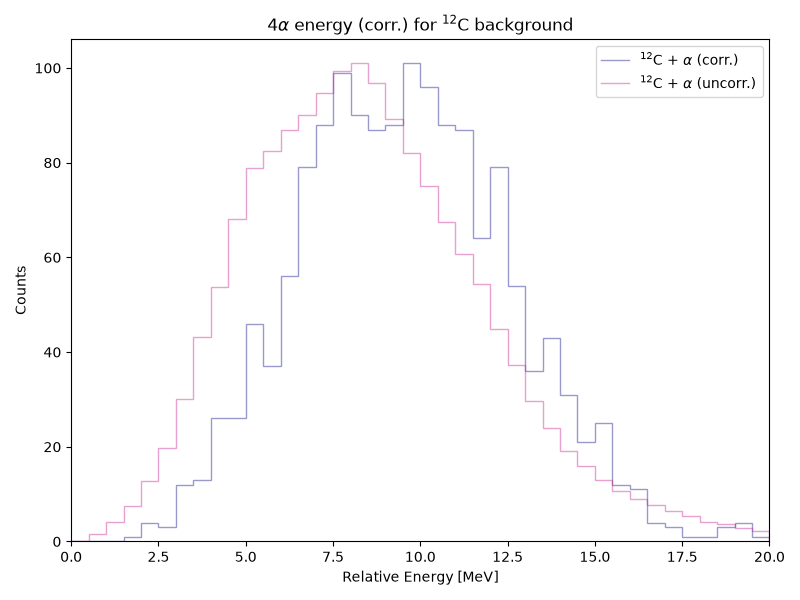

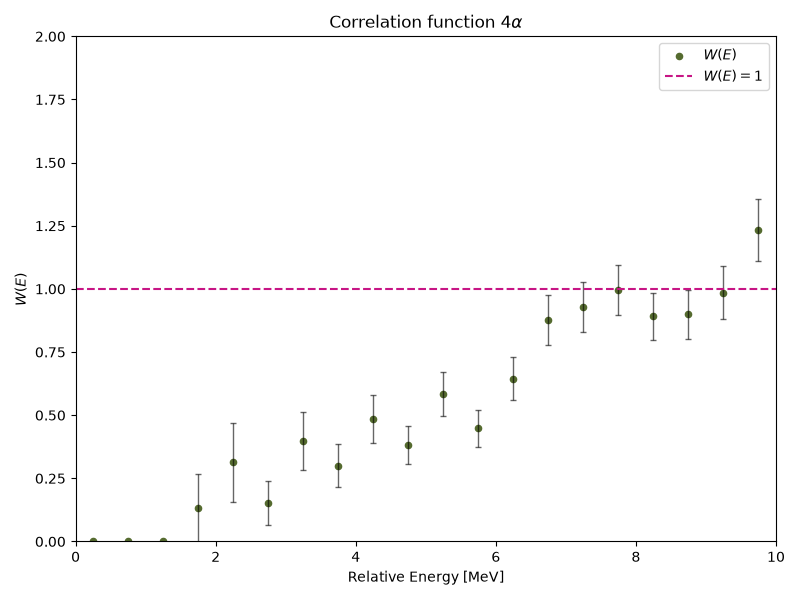

In [11]:
hist_corr = grammer.get_hist1d("inv_12c_correlated")
hist_uncorr = grammer.get_hist1d("inv_12c_uncorrelated")

energy = (hist_corr.bins[:-1] + hist_corr.bins[1:]) / 2

corr = np.asarray(hist_corr.counts, dtype=float)
uncorr = np.asarray(hist_uncorr.counts, dtype=float)

ratio_max = np.max(corr) / np.max(uncorr)

print("Normalization factor =", ratio_max)

uncorr_scaled = uncorr * ratio_max

print("\n========== DIAGNOSTICS ==========")
print("Number of bins:", len(energy))
print("Correlated counts:")
print("  min =", np.min(corr))
print("  max =", np.max(corr))
print("Uncorrelated counts:")
print("  min =", np.min(uncorr))
print("  max =", np.max(uncorr))
print("Zero uncorrelated bins:", np.sum(uncorr == 0))

subtracted = corr - uncorr_scaled

W = np.divide(
    corr,
    uncorr_scaled,
    out=np.full_like(corr, np.nan),
    where=uncorr_scaled > 0
)

print("\nCorrelation function:")
print("  NaN:", np.sum(np.isnan(W)))
print("  Inf:", np.sum(np.isinf(W)))

finite_W = W[np.isfinite(W)]

if len(finite_W) > 0:
    print("  minimum =", np.min(finite_W))
    print("  maximum =", np.max(finite_W))

error_mask = (
    (corr > 0) &
    (uncorr > 0) &
    np.isfinite(W)
)

W_error = np.full_like(W, np.nan)

W_error[error_mask] = (
    W[error_mask]
    * np.sqrt(
        1.0 / corr[error_mask]
        + 1.0 / uncorr[error_mask]
    )
)

print("\nUncertainty:")
print("  valid bins:", np.sum(error_mask))
print("  invalid bins:", np.sum(~error_mask))

fig, ax = plt.subplots(figsize=(8, 6))

ax.stairs(
    corr,
    edges=hist_corr.bins,
    color="navy",
    alpha=0.4,
    label=r"$^{12}$C + $\alpha$ (corr.)"
)

ax.stairs(
    uncorr_scaled,
    edges=hist_uncorr.bins,
    color="mediumvioletred",
    alpha=0.4,
    label=r"$^{12}$C + $\alpha$ (uncorr.)"
)

ax.set_xlabel("Relative Energy [MeV]")
ax.set_ylabel("Counts")
ax.set_title(r"$4\alpha$ energy (corr.) for $^{12}$C background")
ax.set_xlim(0, 20)
ax.legend()

plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(figsize=(8, 6))

# ax.stairs(
#     subtracted,
#     edges=hist_corr.bins,
#     color="darkolivegreen",
#     label=r"$^{12}$C + $\alpha$ (subtracted)"
# )

# ax.axhline(
#     y=0,
#     linestyle="--",
#     color="black",
#     linewidth=1
# )

# ax.set_xlabel("Relative Energy [MeV]")
# ax.set_ylabel("Counts")
# ax.set_title(r"Background-subtracted $4\alpha$ spectrum")
# ax.set_xlim(0, 6)
# ax.legend()

# plt.tight_layout()
# plt.show()

plot_mask = np.isfinite(W)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    energy[plot_mask],
    W[plot_mask],
    color="darkolivegreen",
    s=20,
    label=r"$W(E)$"
)

ax.errorbar(
    energy[error_mask],
    W[error_mask],
    yerr=W_error[error_mask],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=2,
    alpha=0.6
)

ax.axhline(
    y=1,
    linestyle="--",
    color="mediumvioletred",
    linewidth=1.5,
    label=r"$W(E)=1$"
)

ax.set_xlabel("Relative Energy [MeV]")
ax.set_ylabel(r"$W(E)$")
ax.set_title(r"Correlation function $4\alpha$")
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
# fig, ax = plt.subplots(1,1)
# hist_corr = grammer.get_hist1d("inv_12c_correlated")

# hist_uncorr = grammer.get_hist1d("inv_12c_uncorrelated")
# ratio_max = max(hist_corr.counts)/max(hist_uncorr.counts)


# # # popt, pcov = curve_fit(double_gaussian, bin_centers, hist.counts, p0=initial_guess)
# # # x_smooth = np.linspace(hist.bins[0], hist.bins[-1], 200)
# # # y_fit = double_gaussian(x_smooth, *popt)
# # # y_gauss1 = popt[0] * np.exp(-((x_smooth - popt[1]) ** 2) / (2 * popt[2] ** 2))
# # # y_gauss2 = popt[3] * np.exp(-((x_smooth - popt[4]) ** 2) / (2 * popt[5] ** 2))

# ax.stairs(hist_corr.counts, edges=hist_corr.bins, color="navy", label=r"$^{12}$C + $\alpha$ (corr.)", alpha=0.4)
# ax.stairs(hist_uncorr.counts*ratio_max, edges=hist_uncorr.bins, color="mediumvioletred", label=r"$^{12}$C + $\alpha$ (uncorr.)", alpha=0.4)

# subtracted = hist_corr.counts-(hist_uncorr.counts*ratio_counts)

# # print(subtracted)
# ax.stairs(subtracted, edges=hist_corr.bins, color="darkolivegreen", label=r"$^{12}$C + $\alpha$ (subtracted)")
# # ax.axvline(x=7.65, linestyle="--", color="mediumvioletred", label="x=7.65")
# # # plt.plot(x_smooth, y_fit, 'r-', label='Combined Fit', linewidth=2)
# # # plt.plot(x_smooth, y_gauss1, 'g--', label=rf'Gaussian 1 ($\mu$ = {popt[1]:.2f} | $\sigma$ = {popt[2]:.2f})')
# # # plt.plot(x_smooth, y_gauss2, 'b--', label=rf'Gaussian 2 ($\mu$ = {popt[4]:.2f} | $\sigma$ = {popt[5]:.2f})')
# ax.set_xlabel("Relative Energy [MeV]")
# ax.set_ylabel("Counts")
# plt.legend()
# # plt.xlim(0,2)
# # plt.ylim(0,10)
# plt.title(r"$4\alpha$ energy (corr.) for $^{12}$C background ")
# fig.set_figwidth(8.0)
# fig.set_figheight(6.0)
# plt.show()

In [13]:
# fig, ax = plt.subplots(1,1)
# energy = (hist_corr.bins[:-1] + hist_corr.bins[1:]) / 2

# ax.scatter(energy,hist_corr.counts/(hist_uncorr.counts*ratio_max), color="darkolivegreen", label=r"$^{12}$C + $\alpha$ (subtracted)")
# errors = np.sqrt(hist_corr.counts)/np.sqrt(hist_uncorr.counts)
# # ax.errorbar(
# #     x=energy, 
# #     y=hist_corr.counts/(hist_uncorr.counts*ratio_max), 
# #     yerr=errors, 
# #     fmt='o',       # 'none' hides data markers, keeping only error bars
# #     ecolor='black',    # Color of the error bars
# #     elinewidth=1.5,   # Line thickness
# #     capsize=3         # Add small horizontal caps to the top/bottom of bars
# # )
# ax.axhline(y=1, linestyle="--", color="mediumvioletred", label="x=7.65")
# # print(hist_corr.counts*ratio_counts/hist_uncorr.counts)
# # print(energy)
# ax.set_xlabel("Relative Energy [MeV]")
# ax.set_ylabel("W(E)")
# # plt.legend()
# plt.title(r"Correlation function $4\alpha$")
# plt.xlim(0,6)
# plt.ylim(0,2)
# # fig.set_figwidth(8.0)
# # fig.set_figheight(6.0)
# plt.show()

## $^{8}\text{Be}$ Event Mixing

### Uncorrelated Relative Energy

In [14]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

df = concat_df.slice(offset=0,length=400) #limited the amount of original events -> less computation

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 


wide = df.pivot(
    on="cluster_index_corr",
    index="event",
    values=["px", "py", "pz", "E"],
) #collaspsing the 5 different entries from 5 alphas into just the four momentum vector on one entry with different alphas 

# print(wide.shape)
# wide.head()

combo_frames = []
for combo_id, (i, j) in enumerate(combinations(range(5), 2)): #creates a list of 10 tables, one with each combination
    combo_frames.append(
        wide.select(
            pl.col("event"),
            pl.lit(combo_id).alias("combo_id"),
            (pl.col(f"px_{i}") + pl.col(f"px_{j}")).alias("px_tot2"),
            (pl.col(f"py_{i}") + pl.col(f"py_{j}")).alias("py_tot2"),
            (pl.col(f"pz_{i}") + pl.col(f"pz_{j}")).alias("pz_tot2"),
            (pl.col(f"E_{i}")  + pl.col(f"E_{j}")).alias("E_tot2"),
        )
    )

two_sums = pl.concat(combo_frames)

alphas_flat = df.select(["event", "px", "py", "pz", "E"]).rename(
    {"event": "event_mix", "px": "px3rd", "py": "py3rd", "pz": "pz3rd", "E": "E3rd"}
)

mixed = (
    two_sums.lazy()
    .join(alphas_flat.lazy(), how="cross")
    .filter(pl.col("event") != pl.col("event_mix")) #making sure to not include the 4th alphas as the one from the same event 
    .with_columns(
        (pl.col("px_tot2") + pl.col("px3rd")).alias("Px"), #adding the four momentum vector for the 4th alpha and assigning to a total energy
        (pl.col("py_tot2") + pl.col("py3rd")).alias("Py"),
        (pl.col("pz_tot2") + pl.col("pz3rd")).alias("Pz"),
        (pl.col("E_tot2")  + pl.col("E3rd")).alias("Etot"),
    )
    .with_columns(
        pl.max_horizontal(
            pl.col("Etot")**2 - (pl.col("Px")**2 + pl.col("Py")**2 + pl.col("Pz")**2),  #getting the inariant mass
            pl.lit(0.0),
        ).sqrt().alias("inv_mass")
    )
    .with_columns(
        (pl.col("inv_mass") - 3 * ejectile.mass).alias("rel_energy") #getting the relativ energy 
    )
    .collect(engine="streaming")
)


uncorr_total_counts = mixed.height
relative_uncorr = mixed["rel_energy"].to_list()
grammer.fill_hist1d("inv_8be_uncorrelated",relative_uncorr)


True

### Correlated Relative Energy

In [15]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

df = concat_df

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 


wide = df.pivot(
    on="cluster_index_corr",
    index="event",
    values=["px", "py", "pz", "E"],
) #collaspsing the 5 different entries from 5 alphas into just the four momentum vector on one entry with different alphas 

# print(wide.shape)
# wide.head()

combo_frames = []
for combo_id, (i, j, k) in enumerate(combinations(range(5), 3)): #creates a list of 10 tables, one with each combination
    combo_frames.append(
        wide.select(
            pl.col("event"),
            pl.lit(combo_id).alias("combo_id"),
            (pl.col(f"px_{i}") + pl.col(f"px_{j}") + pl.col(f"px_{k}")).alias("Px"),
            (pl.col(f"py_{i}") + pl.col(f"py_{j}") + pl.col(f"py_{k}")).alias("Py"),
            (pl.col(f"pz_{i}") + pl.col(f"pz_{j}") + pl.col(f"pz_{k}")).alias("Pz"),
            (pl.col(f"E_{i}")  + pl.col(f"E_{j}")  + pl.col(f"E_{k}")).alias("Etot"),
        )
    )

three_sums = pl.concat(combo_frames)



mixed = (
    three_sums.lazy()
    .with_columns(
        pl.max_horizontal(
            pl.col("Etot")**2 - (pl.col("Px")**2 + pl.col("Py")**2 + pl.col("Pz")**2),  #getting the inariant mass
            pl.lit(0.0),
        ).sqrt().alias("inv_mass")
    )
    .with_columns(
        (pl.col("inv_mass") - 3 * ejectile.mass).alias("rel_energy") #getting the relativ energy 
    )
    .collect(engine="streaming")
)

corr_total_counts = mixed.height

relative_corr = mixed["rel_energy"].to_list()
grammer.fill_hist1d("inv_8be_correlated",relative_corr)


True

In [16]:
ratio_counts = corr_total_counts/uncorr_total_counts
print(f"Ratio unorr/corr counts: {ratio_counts}")

Ratio unorr/corr counts: 0.013086104006820119


In [17]:
# fig, ax = plt.subplots(1,1)
# hist_corr = grammer.get_hist1d("inv_8be_correlated")

# hist_uncorr = grammer.get_hist1d("inv_8be_uncorrelated")

# ratio_max = max(hist_corr.counts)/max(hist_uncorr.counts)

# # # popt, pcov = curve_fit(double_gaussian, bin_centers, hist.counts, p0=initial_guess)
# # # x_smooth = np.linspace(hist.bins[0], hist.bins[-1], 200)
# # # y_fit = double_gaussian(x_smooth, *popt)
# # # y_gauss1 = popt[0] * np.exp(-((x_smooth - popt[1]) ** 2) / (2 * popt[2] ** 2))
# # # y_gauss2 = popt[3] * np.exp(-((x_smooth - popt[4]) ** 2) / (2 * popt[5] ** 2))

# ax.stairs(hist_corr.counts, edges=hist_corr.bins, color="navy", label=r"$^{8}$Be + $\alpha$ (corr.)", alpha=0.4)
# ax.stairs(hist_uncorr.counts*ratio_max, edges=hist_uncorr.bins, color="mediumvioletred", label=r"$^{8}$Be + $\alpha$ (uncorr.)", alpha=0.4)

# subtracted = hist_corr.counts-hist_uncorr.counts*ratio_counts

# # print(subtracted)
# ax.stairs(subtracted, edges=hist_corr.bins, color="darkolivegreen", label=r"$^{8}$Be + $\alpha$ (subtracted)")
# # ax.axvline(x=7.65, linestyle="--", color="mediumvioletred", label="x=7.65")
# # # plt.plot(x_smooth, y_fit, 'r-', label='Combined Fit', linewidth=2)
# # # plt.plot(x_smooth, y_gauss1, 'g--', label=rf'Gaussian 1 ($\mu$ = {popt[1]:.2f} | $\sigma$ = {popt[2]:.2f})')
# # # plt.plot(x_smooth, y_gauss2, 'b--', label=rf'Gaussian 2 ($\mu$ = {popt[4]:.2f} | $\sigma$ = {popt[5]:.2f})')
# ax.set_xlabel("Relative Energy [MeV]")
# ax.set_ylabel("Counts")
# plt.legend()
# plt.title(r"$3\alpha$ energy (corr.) for $^{8}$Be background ")
# fig.set_figwidth(8.0)
# fig.set_figheight(6.0)
# plt.show()

In [18]:
# fig, ax = plt.subplots(1,1)
# energy = (hist_corr.bins[:-1] + hist_corr.bins[1:]) / 2
# errors = np.sqrt(hist_corr.counts)/np.sqrt(hist_uncorr.counts)
# ax.errorbar(
#     x=energy, 
#     y=hist_corr.counts/(hist_uncorr.counts*ratio_max), 
#     yerr=errors, 
#     fmt='o',       # 'none' hides data markers, keeping only error bars
#     ecolor='black',    # Color of the error bars
#     elinewidth=1.5,   # Line thickness
#     capsize=3         # Add small horizontal caps to the top/bottom of bars
# )
# # ax.scatter(energy,hist_corr.counts/(hist_uncorr.counts*ratio_max), color="darkolivegreen", label=r"$^{12}$C + $\alpha$ (subtracted)")
# ax.axhline(y=1, linestyle="--", color="mediumvioletred", label="x=7.65")
# # print(hist_corr.counts*ratio_counts/hist_uncorr.counts)
# # print(energy)
# ax.set_xlabel("Relative Energy [MeV]")
# ax.set_ylabel("W(E)")
# # plt.legend()
# plt.title(r"Correlation function $3\alpha$")
# plt.xlim(0,20)
# plt.ylim(0,1.5)
# # fig.set_figwidth(8.0)
# # fig.set_figheight(6.0)
# # plt.show()

Normalization factor = 0.012663214768122467

========== DIAGNOSTICS ==========
Number of bins: 40
Correlated counts:
  min = 0.0
  max = 225.0
Uncorrelated counts:
  min = 87.0
  max = 17768.0
Zero uncorrelated bins: 0

Correlation function:
  NaN: 0
  Inf: 0
  minimum = 0.0
  maximum = 2.371438104771438

Uncertainty:
  valid bins: 37
  invalid bins: 3


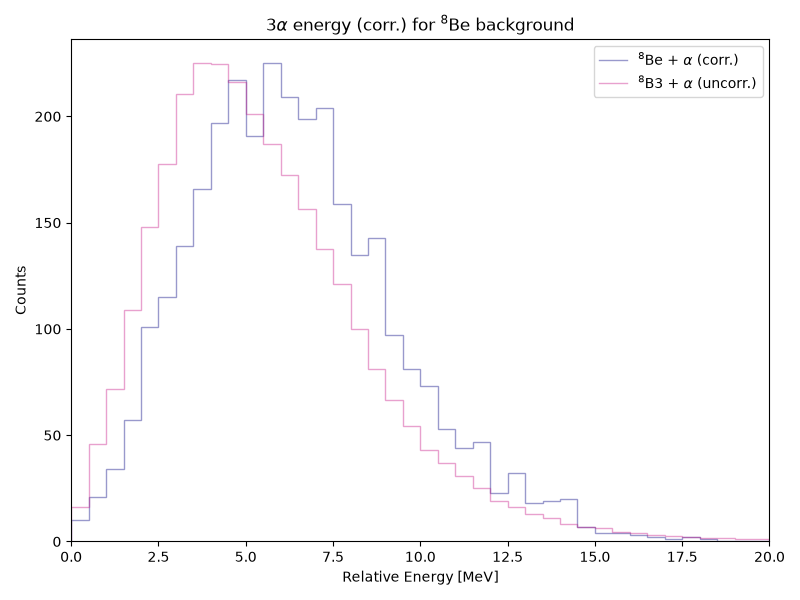

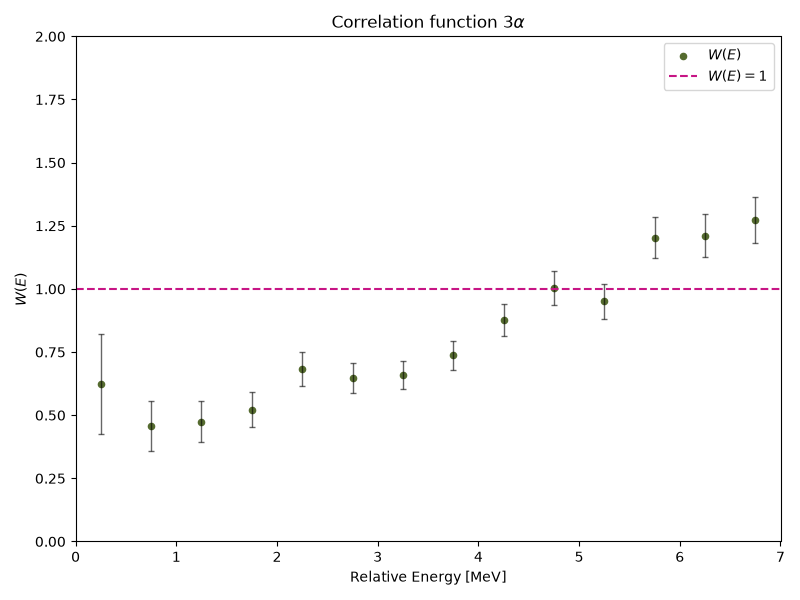

In [19]:
hist_corr = grammer.get_hist1d("inv_8be_correlated")
hist_uncorr = grammer.get_hist1d("inv_8be_uncorrelated")

energy = (hist_corr.bins[:-1] + hist_corr.bins[1:]) / 2

corr = np.asarray(hist_corr.counts, dtype=float)
uncorr = np.asarray(hist_uncorr.counts, dtype=float)

ratio_max = np.max(corr) / np.max(uncorr)

print("Normalization factor =", ratio_max)

uncorr_scaled = uncorr * ratio_max

print("\n========== DIAGNOSTICS ==========")
print("Number of bins:", len(energy))
print("Correlated counts:")
print("  min =", np.min(corr))
print("  max =", np.max(corr))
print("Uncorrelated counts:")
print("  min =", np.min(uncorr))
print("  max =", np.max(uncorr))
print("Zero uncorrelated bins:", np.sum(uncorr == 0))

subtracted = corr - uncorr_scaled

W = np.divide(
    corr,
    uncorr_scaled,
    out=np.full_like(corr, np.nan),
    where=uncorr_scaled > 0
)

print("\nCorrelation function:")
print("  NaN:", np.sum(np.isnan(W)))
print("  Inf:", np.sum(np.isinf(W)))

finite_W = W[np.isfinite(W)]

if len(finite_W) > 0:
    print("  minimum =", np.min(finite_W))
    print("  maximum =", np.max(finite_W))

error_mask = (
    (corr > 0) &
    (uncorr > 0) &
    np.isfinite(W)
)

W_error = np.full_like(W, np.nan)

W_error[error_mask] = (
    W[error_mask]
    * np.sqrt(
        1.0 / corr[error_mask]
        + 1.0 / uncorr[error_mask]
    )
)

print("\nUncertainty:")
print("  valid bins:", np.sum(error_mask))
print("  invalid bins:", np.sum(~error_mask))

fig, ax = plt.subplots(figsize=(8, 6))

ax.stairs(
    corr,
    edges=hist_corr.bins,
    color="navy",
    alpha=0.4,
    label=r"$^{8}$Be + $\alpha$ (corr.)"
)

ax.stairs(
    uncorr_scaled,
    edges=hist_uncorr.bins,
    color="mediumvioletred",
    alpha=0.4,
    label=r"$^{8}$B3 + $\alpha$ (uncorr.)"
)

ax.set_xlabel("Relative Energy [MeV]")
ax.set_ylabel("Counts")
ax.set_title(r"$3\alpha$ energy (corr.) for $^{8}$Be background")
ax.set_xlim(0, 20)
ax.legend()

plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(figsize=(8, 6))

# ax.stairs(
#     subtracted,
#     edges=hist_corr.bins,
#     color="darkolivegreen",
#     label=r"$^{12}$C + $\alpha$ (subtracted)"
# )

# ax.axhline(
#     y=0,
#     linestyle="--",
#     color="black",
#     linewidth=1
# )

# ax.set_xlabel("Relative Energy [MeV]")
# ax.set_ylabel("Counts")
# ax.set_title(r"Background-subtracted $4\alpha$ spectrum")
# ax.set_xlim(0, 6)
# ax.legend()

# plt.tight_layout()
# plt.show()

plot_mask = np.isfinite(W)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    energy[plot_mask],
    W[plot_mask],
    color="darkolivegreen",
    s=20,
    label=r"$W(E)$"
)

ax.errorbar(
    energy[error_mask],
    W[error_mask],
    yerr=W_error[error_mask],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=2,
    alpha=0.6
)

ax.axhline(
    y=1,
    linestyle="--",
    color="mediumvioletred",
    linewidth=1.5,
    label=r"$W(E)=1$"
)

ax.set_xlabel("Relative Energy [MeV]")
ax.set_ylabel(r"$W(E)$")
ax.set_title(r"Correlation function $3\alpha$")
ax.set_xlim(0, 7)
ax.set_ylim(0, 2)
ax.legend()

plt.tight_layout()
plt.show()

### With $2\alpha$ Method

In [20]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

df = concat_df.slice(offset=0,length=400) #limited the amount of original events -> less computation

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 


wide = df.pivot(
    on="cluster_index_corr",
    index="event",
    values=["px", "py", "pz", "E"],
) #collaspsing the 5 different entries from 5 alphas into just the four momentum vector on one entry with different alphas 

alphas_flat_1 = df.select(["event", "px", "py", "pz", "E"]).rename(
    {"event": "event", "px": "px_1", "py": "py_1", "pz": "pz_1", "E": "E_1"}
)

alphas_flat_2 = df.select(["event", "px", "py", "pz", "E"]).rename(
    {"event": "event_mix", "px": "px_2", "py": "py_2", "pz": "pz_2", "E": "E_2"}
)

mixed = (
    alphas_flat_1.lazy()
    .join(alphas_flat_2.lazy(), how="cross")
    .filter(pl.col("event") != pl.col("event_mix")) #making sure to not include the 4th alphas as the one from the same event 
    .with_columns(
        (pl.col("px_1") + pl.col("px_2")).alias("Px"), #adding the four momentum vector for the 4th alpha and assigning to a total energy
        (pl.col("py_1") + pl.col("py_2")).alias("Py"),
        (pl.col("pz_1") + pl.col("pz_2")).alias("Pz"),
        (pl.col("E_1")  + pl.col("E_2")).alias("Etot"),
    )
    .with_columns(
        pl.max_horizontal(
            pl.col("Etot")**2 - (pl.col("Px")**2 + pl.col("Py")**2 + pl.col("Pz")**2),  #getting the inariant mass
            pl.lit(0.0),
        ).sqrt().alias("inv_mass")
    )
    .with_columns(
        (pl.col("inv_mass") - 2 * ejectile.mass).alias("rel_energy") #getting the relativ energy 
    )
    .collect(engine="streaming")
)

uncorr_total_counts_method2 = mixed.height
relative_uncorr = mixed["rel_energy"].to_list()
grammer.fill_hist1d("inv_8be_uncorrelated_method2",relative_uncorr)


True

In [21]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

df = concat_df

df = df.with_row_index("row_id")
counts = (
        df
        .group_by("event")
        .len()
    )

valid_events = (
    counts
    .filter(pl.col("len") == 5)
    .select("event")
)

df = df.join(
    valid_events,
    on="event",
    how="inner"
)


df = df.with_columns(
    (pl.col("brho") * float(ejectile.Z) * QBRHO_2_P).alias("momentum")
).with_columns(
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").cos()).alias("px"),
    (pl.col("momentum") * pl.col("polar").sin() * pl.col("azimuthal").sin()).alias("py"),
    (pl.col("momentum") * pl.col("polar").cos()).alias("pz"),
    (pl.col("momentum")**2 + ejectile.mass**2).sqrt().alias("E"),
) #calculating momentum, px. py. pz, and energy at once 

df = df.with_columns(
    (pl.col("event").cum_count().over("event") - 1).alias("cluster_index_corr")) #cluster index is not always cronological, a new column assigns all enrieswith numbers from 0 - 5 cronologically 


wide = df.pivot(
    on="cluster_index_corr",
    index="event",
    values=["px", "py", "pz", "E"],
) #collaspsing the 5 different entries from 5 alphas into just the four momentum vector on one entry with different alphas 


combo_frames = []
for combo_id, (i, j) in enumerate(combinations(range(5), 2)): #creates a list of 10 tables, one with each combination
    combo_frames.append(
        wide.select(
            pl.col("event"),
            pl.lit(combo_id).alias("combo_id"),
            (pl.col(f"px_{i}") + pl.col(f"px_{j}")).alias("Px"),
            (pl.col(f"py_{i}") + pl.col(f"py_{j}")).alias("Py"),
            (pl.col(f"pz_{i}") + pl.col(f"pz_{j}")).alias("Pz"),
            (pl.col(f"E_{i}")  + pl.col(f"E_{j}") ).alias("Etot"),
        )
    )

two_sums = pl.concat(combo_frames)



mixed = (
    two_sums.lazy()
    .with_columns(
        pl.max_horizontal(
            pl.col("Etot")**2 - (pl.col("Px")**2 + pl.col("Py")**2 + pl.col("Pz")**2),  #getting the inariant mass
            pl.lit(0.0),
        ).sqrt().alias("inv_mass")
    )
    .with_columns(
        (pl.col("inv_mass") - 2 * ejectile.mass).alias("rel_energy") #getting the relativ energy 
    )
    .collect(engine="streaming")
)

corr_total_counts = mixed.height

corr_total_counts_method2 = mixed.height
relative_corr = mixed["rel_energy"].to_list()
grammer.fill_hist1d("inv_8be_correlated_method2",relative_corr)


True

In [22]:
ratio_counts = corr_total_counts/uncorr_total_counts
print(f"Ratio unorr/corr counts: {ratio_counts}")
# print(corr_total_counts,uncorr_total_counts)

Ratio unorr/corr counts: 0.013086104006820119


In [23]:
# fig, ax = plt.subplots(1,1)
# hist_corr = grammer.get_hist1d("inv_8be_correlated_method2")

# hist_uncorr = grammer.get_hist1d("inv_8be_uncorrelated_method2")

# print(max(hist_corr.counts)/max(hist_uncorr.counts))
# ratio_max = max(hist_corr.counts)/max(hist_uncorr.counts)
# # # popt, pcov = curve_fit(double_gaussian, bin_centers, hist.counts, p0=initial_guess)
# # # x_smooth = np.linspace(hist.bins[0], hist.bins[-1], 200)
# # # y_fit = double_gaussian(x_smooth, *popt)
# # # y_gauss1 = popt[0] * np.exp(-((x_smooth - popt[1]) ** 2) / (2 * popt[2] ** 2))
# # # y_gauss2 = popt[3] * np.exp(-((x_smooth - popt[4]) ** 2) / (2 * popt[5] ** 2))

# ax.stairs(hist_corr.counts, edges=hist_corr.bins, color="navy", label=r"$^{8}$Be (corr.)", alpha=0.4)
# ax.stairs(hist_uncorr.counts*ratio_max, edges=hist_uncorr.bins, color="mediumvioletred", label=r"$^{8}$Be (uncorr.)", alpha=0.4)

# # subtracted = hist_corr.counts-hist_uncorr.counts*ratio_counts

# # print(subtracted)
# # ax.stairs(subtracted, edges=hist_corr.bins, color="darkolivegreen", label=r"$^{8}$Be (subtracted)")
# # ax.axvline(x=7.65, linestyle="--", color="mediumvioletred", label="x=7.65")
# # # plt.plot(x_smooth, y_fit, 'r-', label='Combined Fit', linewidth=2)
# # # plt.plot(x_smooth, y_gauss1, 'g--', label=rf'Gaussian 1 ($\mu$ = {popt[1]:.2f} | $\sigma$ = {popt[2]:.2f})')
# # # plt.plot(x_smooth, y_gauss2, 'b--', label=rf'Gaussian 2 ($\mu$ = {popt[4]:.2f} | $\sigma$ = {popt[5]:.2f})')
# ax.set_xlabel("Relative Energy [MeV]")
# ax.set_ylabel("Counts")
# plt.legend()
# plt.title(r"$2\alpha$ energy (corr.) for $^{8}$Be Method 2")
# fig.set_figwidth(8.0)
# fig.set_figheight(6.0)
# plt.show()

In [24]:
# fig, ax = plt.subplots(1,1)
# energy = (hist_corr.bins[:-1] + hist_corr.bins[1:]) / 2
# errors = np.sqrt(hist_corr.counts)/np.sqrt(hist_uncorr.counts)
# ax.errorbar(
#     x=energy, 
#     y=hist_corr.counts/(hist_uncorr.counts*ratio_max), 
#     yerr=errors, 
#     fmt='o',       # 'none' hides data markers, keeping only error bars
#     ecolor='black',    # Color of the error bars
#     elinewidth=1.5,   # Line thickness
#     capsize=3         # Add small horizontal caps to the top/bottom of bars
# )
# # ax.scatter(energy,hist_corr.counts/(hist_uncorr.counts*ratio_max), color="darkolivegreen", label=r"$^{12}$C + $\alpha$ (subtracted)")
# ax.axhline(y=1, linestyle="--", color="mediumvioletred", label="x=7.65")
# # print(hist_corr.counts*ratio_counts/hist_uncorr.counts)
# # print(energy)
# ax.set_xlabel("Relative Energy [MeV]")
# ax.set_ylabel("W(E)")
# # plt.legend()
# plt.title(r"Correlation function $2\alpha$")
# plt.xlim(0,6)
# plt.ylim(0,1.5)
# # fig.set_figwidth(8.0)
# # fig.set_figheight(6.0)
# # plt.show()

Normalization factor = 0.023110638863062825

========== DIAGNOSTICS ==========
Number of bins: 40
Correlated counts:
  min = 0.0
  max = 348.0
Uncorrelated counts:
  min = 2.0
  max = 15058.0
Zero uncorrelated bins: 0

Correlation function:
  NaN: 0
  Inf: 0
  minimum = 0.0
  maximum = 10.817528735632184

Uncertainty:
  valid bins: 32
  invalid bins: 8


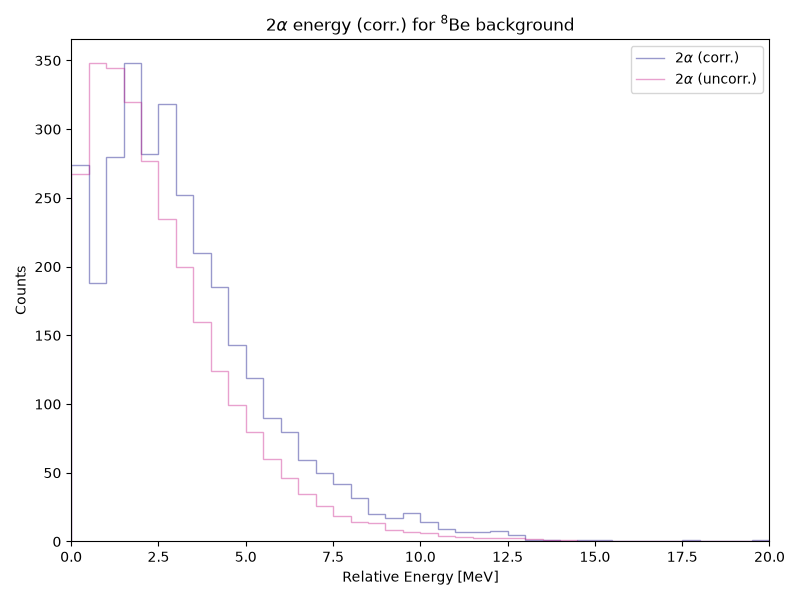

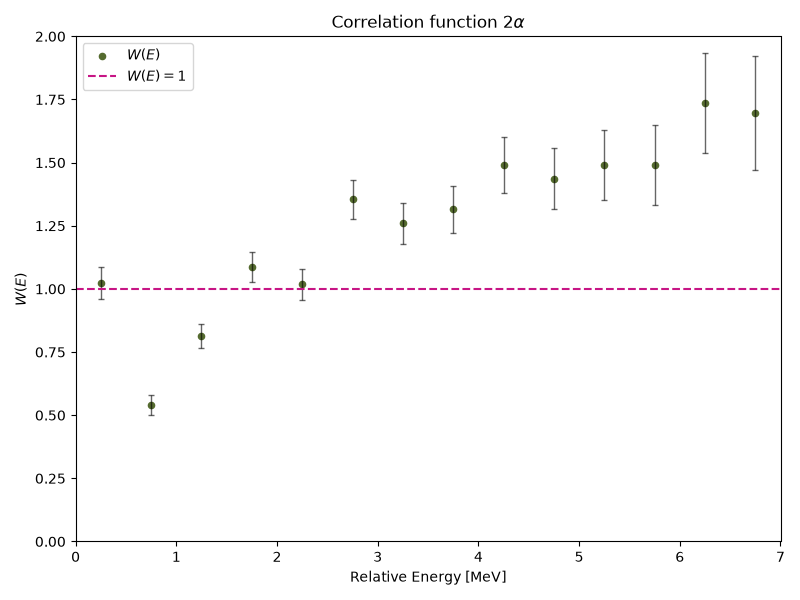

In [25]:
hist_corr = grammer.get_hist1d("inv_8be_correlated_method2")
hist_uncorr = grammer.get_hist1d("inv_8be_uncorrelated_method2")

energy = (hist_corr.bins[:-1] + hist_corr.bins[1:]) / 2

corr = np.asarray(hist_corr.counts, dtype=float)
uncorr = np.asarray(hist_uncorr.counts, dtype=float)

ratio_max = np.max(corr) / np.max(uncorr)

print("Normalization factor =", ratio_max)

uncorr_scaled = uncorr * ratio_max

print("\n========== DIAGNOSTICS ==========")
print("Number of bins:", len(energy))
print("Correlated counts:")
print("  min =", np.min(corr))
print("  max =", np.max(corr))
print("Uncorrelated counts:")
print("  min =", np.min(uncorr))
print("  max =", np.max(uncorr))
print("Zero uncorrelated bins:", np.sum(uncorr == 0))

subtracted = corr - uncorr_scaled

W = np.divide(
    corr,
    uncorr_scaled,
    out=np.full_like(corr, np.nan),
    where=uncorr_scaled > 0
)

print("\nCorrelation function:")
print("  NaN:", np.sum(np.isnan(W)))
print("  Inf:", np.sum(np.isinf(W)))

finite_W = W[np.isfinite(W)]

if len(finite_W) > 0:
    print("  minimum =", np.min(finite_W))
    print("  maximum =", np.max(finite_W))

error_mask = (
    (corr > 0) &
    (uncorr > 0) &
    np.isfinite(W)
)

W_error = np.full_like(W, np.nan)

W_error[error_mask] = (
    W[error_mask]
    * np.sqrt(
        1.0 / corr[error_mask]
        + 1.0 / uncorr[error_mask]
    )
)

print("\nUncertainty:")
print("  valid bins:", np.sum(error_mask))
print("  invalid bins:", np.sum(~error_mask))

fig, ax = plt.subplots(figsize=(8, 6))

ax.stairs(
    corr,
    edges=hist_corr.bins,
    color="navy",
    alpha=0.4,
    label=r"$2\alpha$ (corr.)"
)

ax.stairs(
    uncorr_scaled,
    edges=hist_uncorr.bins,
    color="mediumvioletred",
    alpha=0.4,
    label=r"$2\alpha$ (uncorr.)"
)

ax.set_xlabel("Relative Energy [MeV]")
ax.set_ylabel("Counts")
ax.set_title(r"$2\alpha$ energy (corr.) for $^{8}$Be background")
ax.set_xlim(0, 20)
ax.legend()

plt.tight_layout()
plt.show()

# fig, ax = plt.subplots(figsize=(8, 6))

# ax.stairs(
#     subtracted,
#     edges=hist_corr.bins,
#     color="darkolivegreen",
#     label=r"$^{12}$C + $\alpha$ (subtracted)"
# )

# ax.axhline(
#     y=0,
#     linestyle="--",
#     color="black",
#     linewidth=1
# )

# ax.set_xlabel("Relative Energy [MeV]")
# ax.set_ylabel("Counts")
# ax.set_title(r"Background-subtracted $4\alpha$ spectrum")
# ax.set_xlim(0, 6)
# ax.legend()

# plt.tight_layout()
# plt.show()

plot_mask = np.isfinite(W)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    energy[plot_mask],
    W[plot_mask],
    color="darkolivegreen",
    s=20,
    label=r"$W(E)$"
)

ax.errorbar(
    energy[error_mask],
    W[error_mask],
    yerr=W_error[error_mask],
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=2,
    alpha=0.6
)

ax.axhline(
    y=1,
    linestyle="--",
    color="mediumvioletred",
    linewidth=1.5,
    label=r"$W(E)=1$"
)

ax.set_xlabel("Relative Energy [MeV]")
ax.set_ylabel(r"$W(E)$")
ax.set_title(r"Correlation function $2\alpha$")
ax.set_xlim(0, 7)
ax.set_ylim(0, 2)
ax.legend()

plt.tight_layout()
plt.show()